# Method 2: Fairness Regularization (Group Disparity Minimization)

## Definition
Fairness Regularization introduces a **penalty term in the loss function** that discourages large performance differences between demographic groups.

Instead of explicitly boosting minority groups, the model is trained to **minimize disparity between the best and worst performing groups**.

## Loss Function
$L = CE + \lambda (\max_r L_r - \min_r L_r)$

where:

- $CE$ = standard cross entropy loss  
- $L_r$ = average loss for race $r$  
- $\lambda$ = fairness regularization strength

## Intuition
If one group has significantly higher loss than others, the penalty increases, forcing the model to reduce this imbalance.

## Effect
- Directly reduces **performance gap between groups**
- Encourages balanced learning across demographic groups

## Advantage
- More principled fairness objective
- Works across datasets and protected attributes

---


# Summary

| Method | Main Idea | Goal |
|------|------|------|
| Dynamic Weighted Cross Entropy | Increase importance of underperforming groups | Improve minority group accuracy |
| Fairness Regularization | Penalize disparity between groups | Reduce performance gap |
| Adversarial Fairness Learning | Remove race information from representations | Learn bias-invariant features |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Datasets/UTKFace.zip" -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/UTKFace/53_0_1_20170116191725055.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_1_20170116192938845.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_1_20170117181950281.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_1_20170120222553113.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_1_20170120222956787.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_1_20170120223004304.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170104210010763.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170112215433623.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170112221930338.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170116192925824.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170116192934154.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_2_20170119205816456.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_3_20170104220848558.jpg.chip.jpg  
  inflating: /content/UTKFace/53_0_3_20

In [3]:
!ls /content/UTKFace | head


10_0_0_20161220222308131.jpg.chip.jpg
10_0_0_20170103200329407.jpg.chip.jpg
10_0_0_20170103200522151.jpg.chip.jpg
10_0_0_20170103233459275.jpg.chip.jpg
10_0_0_20170104013211746.jpg.chip.jpg
10_0_0_20170110215927291.jpg.chip.jpg
10_0_0_20170110220033115.jpg.chip.jpg
10_0_0_20170110220111082.jpg.chip.jpg
10_0_0_20170110220235233.jpg.chip.jpg
10_0_0_20170110220251986.jpg.chip.jpg


Device: cuda
Valid images: 23695

Running Baseline FL
Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed
Round 6 completed
Round 7 completed
Round 8 completed
Round 9 completed
Round 10 completed

Baseline Race Accuracy
White : 0.885
Black : 0.913
Asian : 0.829
Indian : 0.915
Others : 0.863
Baseline Gap: 0.0852

Running Fairness Regularized FL
Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed
Round 6 completed
Round 7 completed
Round 8 completed
Round 9 completed
Round 10 completed

Fairness FL Race Accuracy
White : 0.878
Black : 0.914
Asian : 0.813
Indian : 0.904
Others : 0.844
Fairness Gap: 0.1013


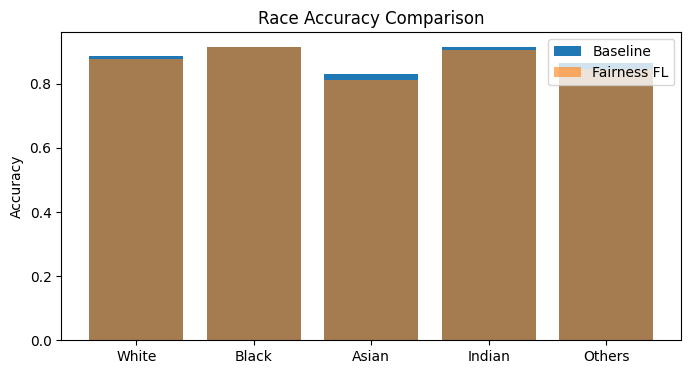

In [4]:
# =========================================================
# FairFed Method-2: Fairness Regularization in Federated Learning
# =========================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------

DATA_DIR = "/content/UTKFace"

NUM_CLIENTS = 10
FAIR_CLIENT_RATIO = 0.3
ROUNDS = 10

BATCH_SIZE = 32
IMG_SIZE = 64
LR = 1e-3

FAIRNESS_LAMBDA = 0.7

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device:", DEVICE)

RACE_MAP = {
0:"White",
1:"Black",
2:"Asian",
3:"Indian",
4:"Others"
}

# ---------------- DATASET ----------------

class UTKFaceDataset(Dataset):

    def __init__(self, root, files, transform=None):

        self.root = root
        self.files = files
        self.transform = transform

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]
        path = os.path.join(self.root, name)

        img = Image.open(path).convert("RGB")

        base = name.replace(".jpg.chip.jpg","")
        parts = base.split("_")

        gender = int(parts[1])
        race = int(parts[2])

        if self.transform:
            img = self.transform(img)

        return img, gender, race

# ---------------- MODEL ----------------

class GenderCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*16*16,128),
            nn.ReLU(),

            nn.Linear(128,2)
        )

    def forward(self,x):

        return self.net(x)

# ---------------- UTIL FUNCTIONS ----------------

def get_weights(model):

    return [p.detach().cpu().numpy() for p in model.parameters()]


def set_weights(model, weights):

    for p, w in zip(model.parameters(), weights):
        p.data = torch.tensor(w).to(DEVICE)


def fedavg(weights):

    return [np.mean(w, axis=0) for w in zip(*weights)]

# ---------------- DATA PREP ----------------

def is_valid_utk(name):

    try:

        base = name.replace(".jpg.chip.jpg","")
        parts = base.split("_")

        race = int(parts[2])

        return race in [0,1,2,3,4]

    except:
        return False


files = [f for f in os.listdir(DATA_DIR) if f.endswith(".jpg.chip.jpg")]
files = [f for f in files if is_valid_utk(f)]

print("Valid images:", len(files))

train_f, test_f = train_test_split(files, test_size=0.2, random_state=SEED)

client_data = np.array_split(train_f, NUM_CLIENTS)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

test_loader = DataLoader(
    UTKFaceDataset(DATA_DIR,test_f,transform),
    batch_size=128,
    shuffle=False
)

# ---------------- TRAIN FUNCTIONS ----------------

def train(model, loader):

    model.train()

    opt = torch.optim.Adam(model.parameters(), lr=LR)
    ce = nn.CrossEntropyLoss()

    for x,y,_ in loader:

        x,y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()

        out = model(x)

        loss = ce(out,y)

        loss.backward()
        opt.step()


def train_fair(model, loader):

    model.train()

    opt = torch.optim.Adam(model.parameters(), lr=LR)
    ce = nn.CrossEntropyLoss(reduction="none")

    for x,y,r in loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)
        r = r.to(DEVICE)

        opt.zero_grad()

        out = model(x)

        sample_losses = ce(out,y)

        race_losses = []

        for race_id in torch.unique(r):

            idx = (r == race_id)

            race_loss = sample_losses[idx].mean()

            race_losses.append(race_loss)

        race_losses = torch.stack(race_losses)

        fairness_penalty = race_losses.max() - race_losses.min()

        loss = sample_losses.mean() + FAIRNESS_LAMBDA * fairness_penalty

        loss.backward()
        opt.step()

# ---------------- EVALUATION ----------------

def evaluate(model, loader):

    model.eval()

    preds=[]
    labels=[]
    races=[]

    with torch.no_grad():

        for x,y,r in loader:

            x = x.to(DEVICE)

            p = model(x).argmax(1).cpu().numpy()

            preds.extend(p)
            labels.extend(y.numpy())
            races.extend(r.numpy())

    return np.array(preds), np.array(labels), np.array(races)

# ---------------- METRICS ----------------

def race_accuracy(preds,labels,races):

    results = {}

    for race in sorted(np.unique(races)):

        idx = races == race

        acc = (preds[idx] == labels[idx]).mean()

        results[race] = acc

    return results

def gap(acc):

    return max(acc.values()) - min(acc.values())

# =========================================================
# BASELINE FEDERATED LEARNING
# =========================================================

def run_fl():

    global_model = GenderCNN().to(DEVICE)

    for rnd in range(ROUNDS):

        client_weights = []

        for cid in range(NUM_CLIENTS):

            local_model = GenderCNN().to(DEVICE)

            set_weights(local_model, get_weights(global_model))

            loader = DataLoader(
                UTKFaceDataset(DATA_DIR, client_data[cid], transform),
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            train(local_model, loader)

            client_weights.append(get_weights(local_model))

        set_weights(global_model, fedavg(client_weights))

        print("Round", rnd+1, "completed")

    preds,labels,races = evaluate(global_model, test_loader)

    return preds,labels,races

# =========================================================
# FAIRNESS FEDERATED LEARNING
# =========================================================

def run_fl_fair():

    global_model = GenderCNN().to(DEVICE)

    fairness_clients = set(
        random.sample(range(NUM_CLIENTS), int(NUM_CLIENTS * FAIR_CLIENT_RATIO))
    )

    for rnd in range(ROUNDS):

        client_weights = []

        for cid in range(NUM_CLIENTS):

            local_model = GenderCNN().to(DEVICE)

            set_weights(local_model, get_weights(global_model))

            loader = DataLoader(
                UTKFaceDataset(DATA_DIR, client_data[cid], transform),
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            if cid in fairness_clients:

                train_fair(local_model, loader)

            else:

                train(local_model, loader)

            client_weights.append(get_weights(local_model))

        set_weights(global_model, fedavg(client_weights))

        print("Round", rnd+1, "completed")

    preds,labels,races = evaluate(global_model, test_loader)

    return preds,labels,races

# =========================================================
# RUN EXPERIMENTS
# =========================================================

print("\nRunning Baseline FL")

preds,labels,races = run_fl()

baseline_acc = race_accuracy(preds,labels,races)

print("\nBaseline Race Accuracy")

for r,a in baseline_acc.items():
    print(RACE_MAP[r],":",round(a,3))

print("Baseline Gap:", round(gap(baseline_acc),4))


print("\nRunning Fairness Regularized FL")

preds_f,labels_f,races_f = run_fl_fair()

fair_acc = race_accuracy(preds_f,labels_f,races_f)

print("\nFairness FL Race Accuracy")

for r,a in fair_acc.items():
    print(RACE_MAP[r],":",round(a,3))

print("Fairness Gap:", round(gap(fair_acc),4))

# =========================================================
# PLOT RESULTS
# =========================================================

races_names = [RACE_MAP[r] for r in baseline_acc.keys()]

plt.figure(figsize=(8,4))

plt.bar(races_names, baseline_acc.values(), label="Baseline")
plt.bar(races_names, fair_acc.values(), alpha=0.6, label="Fairness FL")

plt.ylabel("Accuracy")
plt.title("Race Accuracy Comparison")

plt.legend()

plt.show()